# LIBRARY

In [89]:
import gzip
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score
import warnings
import gzip
import pickle
import ast
 
import numpy as np
import pandas as pd
from tslearn.clustering import TimeSeriesKMeans
from tslearn.metrics import cdist_dtw
from scipy.spatial.distance import cdist
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import DBSCAN
warnings.filterwarnings('ignore')

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PREPARATION

## LOAD DATASET

In [90]:
MOTIFS_CSV   = "../1.DATASET/motifs_discords.csv"
DATASET_PATH = "../1.DATASET/CMI_timeseries_personalized.pkl.gz"
CHANNELS     = ["X", "Y", "Z", "enmo", "anglez", "light"]
W            = 17
COLS_TO_DROP = ["battery_voltage", "timestamp", "quarter",
                "relative_date_PCIAT", "non-wear_flag", "weekday"]
 
# Set to True to also include discord windows in the feature vector
# Recommendation: start with False — motifs are more stable and interpretable
USE_DISCORDS = False

In [91]:
with gzip.open(DATASET_PATH, "rb") as f:
    CMI = pickle.load(f)

data_clean = [df.drop(columns=COLS_TO_DROP, errors="ignore") for df in CMI]
print(f"  {len(data_clean)} subjects loaded")


  4307 subjects loaded


In [92]:
# ── Extract sii_binary labels (one per subject, before dropping columns) ──
y_labels = np.array([
    df["sii_binary"].dropna().iloc[0]   # same value repeated for all rows
    if "sii_binary" in df.columns else np.nan
    for df in CMI
], dtype=float)

print(f"  Labels extracted: {len(y_labels)} subjects")
print(f"  label=0: {(y_labels==0).sum()}  label=1: {(y_labels==1).sum()}  NaN: {np.isnan(y_labels).sum()}")

  Labels extracted: 4307 subjects
  label=0: 2887  label=1: 1420  NaN: 0


## NORMALIZATION

In [93]:
signals = ["X", "Y", "Z", "enmo", "anglez", "light"]

In [94]:
def fit_global_scalers(df_list, signals):
    """Fit one RobustScaler per signal using TRAIN data only."""
    global_scalers = {}
    print("Fitting global scalers on train data...")
    for signal in signals:
        all_values = []
        for df in df_list:
            if signal not in df.columns:
                continue
            y = df[signal].values
            if np.std(y) < 0.0001 or np.ptp(y) == 0:
                continue
            all_values.append(y)
        if not all_values:
            continue
        population = np.concatenate(all_values).reshape(-1, 1)
        q25, q75   = np.percentile(population, [25, 75])
        iqr        = q75 - q25
        signal_std = np.std(population)
        if iqr > 1e-4:
            scaler = RobustScaler()
            scaler.fit(population)
            global_scalers[signal] = ("robust", scaler)
            print(f"  {signal:<18} → RobustScaler   (IQR={iqr:.4f})")
        elif signal_std > 1e-6:
            global_scalers[signal] = ("std_fallback", np.median(population), signal_std)
            print(f"  {signal:<18} → Std fallback   (IQR too small)")
        else:
            global_scalers[signal] = ("zero", None)
            print(f"  {signal:<18} → Zeroed")
    return global_scalers


In [95]:
def apply_global_scalers(df_list, global_scalers):
    """Apply pre-fitted scalers to a list of DataFrames."""
    scaled_list = []
    for df in df_list:
        target_df = df.copy()
        for signal, scaler_info in global_scalers.items():
            if signal not in target_df.columns:
                continue
            y    = target_df[signal].values.copy()
            kind = scaler_info[0]
            if kind == "robust":
                _, scaler = scaler_info
                y_scaled  = scaler.transform(y.reshape(-1, 1)).flatten()
            elif kind == "std_fallback":
                _, median, std = scaler_info
                y_scaled  = (y - median) / std
            else:
                y_scaled  = np.zeros_like(y)
            target_df[signal] = y_scaled
        scaled_list.append(target_df)
    return scaled_list


In [96]:
global_scalers = fit_global_scalers(data_clean, signals)

all_scaled = apply_global_scalers(
    data_clean,
    global_scalers
)

Fitting global scalers on train data...
  X                  → RobustScaler   (IQR=0.8341)
  Y                  → RobustScaler   (IQR=0.4156)
  Z                  → RobustScaler   (IQR=0.4314)
  enmo               → RobustScaler   (IQR=0.0454)
  anglez             → RobustScaler   (IQR=5.6440)
  light              → RobustScaler   (IQR=1.8208)


## LOAD MOTIF DATASET

In [97]:
print("Loading motifs CSV …")
motifs_df = pd.read_csv(MOTIFS_CSV)

# Parse stringified lists safely
for col in motifs_df.columns:
    if col != "sample_index":
        motifs_df[col] = motifs_df[col].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )

Loading motifs CSV …


In [98]:
motifs_df

,sample_index,X_motifs,X_discords,Y_motifs,Y_discords,Z_motifs,Z_discords,enmo_motifs,enmo_discords,anglez_motifs,anglez_discords,light_motifs,light_discords
0,0,"[111, 156, 67]","[180, 7, 181]","[183, 37, 36]","[34, 40, 31]","[52, 74, 20]","[40, 37, 36]","[67, 1, 3]","[183, 182, 165]","[71, 22, 70]","[118, 38, 8]","[114, 150, 108]","[45, 80, 46]"
1,1,"[52, 166, 165]","[68, 171, 69]","[40, 133, 41]","[61, 73, 62]","[148, 32, 147]","[183, 155, 182]","[40, 101, 41]","[24, 157, 26]","[120, 79, 55]","[134, 151, 164]","[28, 9, 30]","[129, 56, 127]"
2,2,"[127, 173, 128]","[29, 30, 49]","[136, 90, 89]","[159, 52, 160]","[132, 19, 31]","[165, 86, 60]","[23, 110, 104]","[44, 11, 42]","[80, 41, 79]","[5, 4, 2]","[24, 15, 23]","[129, 66, 177]"
3,3,"[157, 16, 125]","[37, 36, 90]","[52, 13, 12]","[131, 43, 120]","[23, 1, 142]","[146, 124, 51]","[44, 165, 0]","[98, 97, 109]","[1, 53, 23]","[127, 60, 59]","[4, 19, 18]","[109, 161, 97]"
4,4,"[14, 6, 12]","[39, 40, 81]","[77, 10, 74]","[169, 112, 114]","[23, 165, 169]","[129, 99, 98]","[44, 63, 46]","[150, 171, 153]","[107, 149, 148]","[140, 100, 128]","[0, 24, 25]","[57, 56, 135]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4302,4302,"[19, 13, 23]","[121, 120, 118]","[79, 175, 159]","[105, 104, 122]","[183, 181, 177]","[180, 179, 178]","[154, 160, 153]","[54, 55, 53]","[183, 175, 176]","[134, 180, 179]","[0, 117, 118]","[183, 57, 66]"
4303,4303,"[181, 13, 14]","[161, 160, 159]","[0, 27, 28]","[159, 51, 97]","[57, 94, 68]","[90, 9, 6]","[0, 27, 28]","[86, 99, 83]","[182, 53, 54]","[21, 126, 73]","[0, 27, 28]","[105, 92, 104]"
4304,4304,"[183, 152, 128]","[149, 44, 49]","[183, 152, 153]","[18, 84, 19]","[86, 38, 39]","[182, 183, 132]","[183, 75, 74]","[98, 99, 97]","[68, 116, 69]","[146, 145, 178]","[0, 117, 118]","[183, 57, 66]"
4305,4305,"[0, 143, 148]","[107, 15, 53]","[152, 177, 183]","[1, 2, 26]","[178, 172, 180]","[1, 3, 0]","[0, 150, 149]","[52, 61, 96]","[147, 158, 146]","[0, 3, 2]","[169, 13, 168]","[113, 112, 24]"


## SIGNAL RETRIEVAL

In [99]:
# For every subject, for every channel, pull the raw windows
# at each motif start index  →  store as fixed-length vectors

In [100]:
def extract_windows(ts: np.ndarray, indices: list[int], w: int) -> list[np.ndarray]:
    """Return list of length-w windows; skip any that go out of bounds."""
    windows = []
    for idx in indices:
        if idx + w <= len(ts):
            windows.append(ts[idx: idx + w])
    return windows

In [101]:
def motif_medoid(windows: list) -> np.ndarray:
    """Restituisce la finestra più centrale (medoid) tra quelle disponibili."""
    if len(windows) == 0:
        return None
    if len(windows) == 1:
        return windows[0]
    X = np.vstack(windows)                    # (n_motifs, W)
    D = cdist(X, X, metric="euclidean")
    medoid_idx = np.argmin(D.sum(axis=1))
    return X[medoid_idx] 

In [102]:
records = []

for _, row in motifs_df.iterrows():
    subj_idx = int(row["sample_index"])
    df_subj  = all_scaled[subj_idx]

    subj_features = {"sample_index": subj_idx}

    for ch in CHANNELS:
        if ch not in df_subj.columns:
            subj_features[f"{ch}_motif_medoid"]   = np.zeros(W)
            subj_features[f"{ch}_discord_medoid"] = np.zeros(W)
            continue

        ts           = df_subj[ch].values.astype(float)
        motif_idxs   = row[f"{ch}_motifs"]
        discord_idxs = row[f"{ch}_discords"]

        motif_wins   = extract_windows(ts, motif_idxs,   W)
        discord_wins = extract_windows(ts, discord_idxs, W)

        subj_features[f"{ch}_motif_medoid"]   = (
            motif_medoid(motif_wins)   if motif_wins   else np.zeros(W)
        )
        subj_features[f"{ch}_discord_medoid"] = (
            motif_medoid(discord_wins) if discord_wins else np.zeros(W)
        )

    records.append(subj_features)

print(f"  Built {len(records)} subject records")

  Built 4307 subject records


## BUILD 3D FEATURE MATRIX

In [103]:
if USE_DISCORDS:
    X_3d = np.array([
        np.hstack([
            np.stack([r[f"{ch}_motif_medoid"]   for ch in CHANNELS], axis=1),
            np.stack([r[f"{ch}_discord_medoid"] for ch in CHANNELS], axis=1),
        ])
        for r in records
    ])
    print(f"Feature matrix shape (motifs + discords): {X_3d.shape}")
else:
    X_3d = np.array([
        np.stack([r[f"{ch}_motif_medoid"] for ch in CHANNELS], axis=1)
        for r in records
    ])
    print(f"Feature matrix shape (motifs only): {X_3d.shape}")

Feature matrix shape (motifs only): (4307, 17, 6)


# Hierarchical clustering

## distance matrix

In [104]:
print("Computing DTW distance matrix (this may take a while) ...")
sakoe_radius = 10 # max(1, int(0.05 * W))
dist_mat = cdist_dtw(
    X_3d,
    global_constraint="sakoe_chiba",
    sakoe_chiba_radius=sakoe_radius
)
print(f"  Distance matrix shape: {dist_mat.shape}")

print("Building linkage matrix ...")
condensed = squareform(dist_mat)
Z         = linkage(condensed, method="complete") ##average


Computing DTW distance matrix (this may take a while) ...
  Distance matrix shape: (4307, 4307)
Building linkage matrix ...


## OPTIMAL NUMBER OF CLUSTERS

In [105]:
from sklearn.metrics import silhouette_score

print("\n" + "="*60)
print("FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*60)

# Test different k values
k_range = range(2, 13)
silhouette_scores = []

for k in k_range:
    labels = fcluster(Z, k, criterion='maxclust')
    if len(set(labels)) > 1:
        # Convert to 0-indexed for silhouette
        sil = silhouette_score(dist_mat, labels, metric='precomputed')
        silhouette_scores.append(sil)
        print(f"  k={k:2d}: silhouette={sil:.4f}")
    else:
        silhouette_scores.append(-1)
        print(f"  k={k:2d}: only 1 cluster")






FINDING OPTIMAL NUMBER OF CLUSTERS
  k= 2: silhouette=0.9869
  k= 3: silhouette=0.9511
  k= 4: silhouette=0.8512
  k= 5: silhouette=0.8414
  k= 6: silhouette=0.5117
  k= 7: silhouette=0.5095
  k= 8: silhouette=0.5096
  k= 9: silhouette=0.5112
  k=10: silhouette=0.4909
  k=11: silhouette=0.5009
  k=12: silhouette=0.5009


In [106]:
best_k = 6
# Get cluster labels for best k
cluster_labels = fcluster(Z, best_k, criterion='maxclust')

## SWEEP k  →  silhouette + SSE on precomputed dist_mat



Sweeping k ...
  k= 2  silhouette=0.9869  SSE=876873.10
  k= 3  silhouette=0.9511  SSE=774156.67
  k= 4  silhouette=0.8512  SSE=705754.28
  k= 5  silhouette=0.8414  SSE=685504.56
  k= 6  silhouette=0.5117  SSE=652753.01
  k= 7  silhouette=0.5095  SSE=639719.24
  k= 8  silhouette=0.5096  SSE=630989.41
  k= 9  silhouette=0.5112  SSE=617637.62
  k=10  silhouette=0.4909  SSE=608660.54
  k=11  silhouette=0.5009  SSE=551275.93
  k=12  silhouette=0.5009  SSE=548335.88
  k=13  silhouette=0.3191  SSE=501102.63
  k=14  silhouette=0.2862  SSE=454494.35
  k=15  silhouette=0.2703  SSE=442436.88
  k=16  silhouette=0.2700  SSE=438395.50


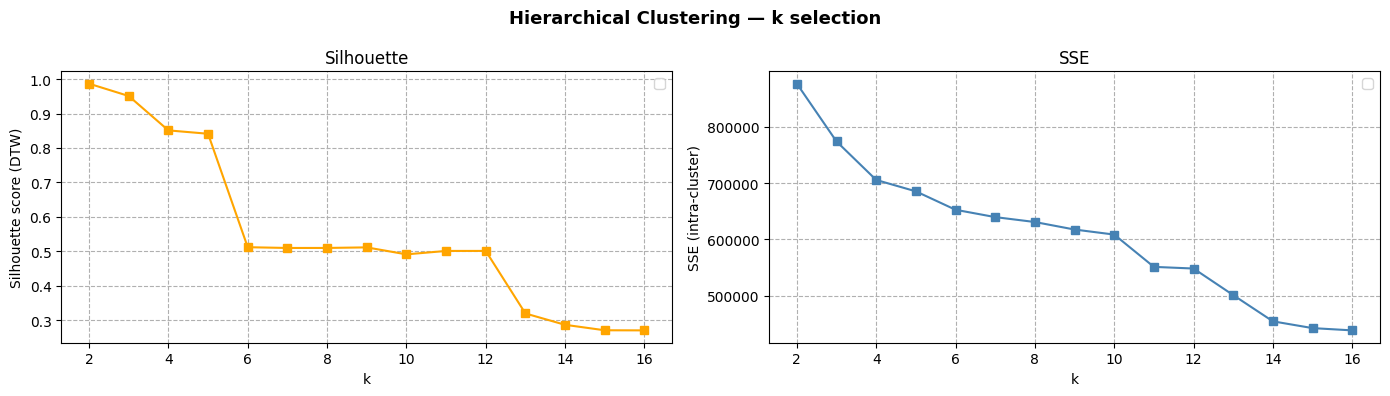

In [107]:

k_range  = range(2, 17)
sil_list = []
sse_list = []

print("\nSweeping k ...")
for k in k_range:
    labels = fcluster(Z, t=k, criterion="maxclust") - 1  # 0-indexed

    # Silhouette — measures cluster separation
    sil = silhouette_score(dist_mat, labels, metric="precomputed")
    sil_list.append(sil)

    # SSE — sum of squared distances from each point to its cluster centroid
    # Using precomputed dist_mat: for each cluster, sum squared intra-cluster distances
    sse = 0.0
    for c in range(k):
        mask     = np.where(labels == c)[0]
        sub_dist = dist_mat[np.ix_(mask, mask)]
        # Mean distance to cluster center (most central point)
        sse += (sub_dist ** 2).sum() / (2 * len(mask)) if len(mask) > 0 else 0
    sse_list.append(sse)

    print(f"  k={k:2d}  silhouette={sil:.4f}  SSE={sse:.2f}")

# ── Plot both metrics side by side ───────────────────────────────────────────
auto_best_k = list(k_range)[int(np.argmax(sil_list))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Hierarchical Clustering — k selection", fontsize=13, fontweight="bold")

# Silhouette
ax1.plot(list(k_range), sil_list, "s-", color="orange")
#ax1.axvline(auto_best_k, ls="--", color="red", label=f"best k={auto_best_k}")
ax1.set_xlabel("k")
ax1.set_ylabel("Silhouette score (DTW)")
ax1.set_title("Silhouette")
ax1.legend()
ax1.grid(linestyle="--")

# SSE (elbow)
ax2.plot(list(k_range), sse_list, "s-", color="steelblue")
#ax2.axvline(auto_best_k, ls="--", color="red", label=f"silhouette best k={auto_best_k}")
ax2.set_xlabel("k")
ax2.set_ylabel("SSE (intra-cluster)")
ax2.set_title("SSE")
ax2.legend()
ax2.grid(linestyle="--")

plt.tight_layout()
plt.show()

In [108]:
k = 12
cluster_labels = fcluster(Z, best_k, criterion='maxclust') - 1

# Define 6 distinct colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

## DENDROGRAM


Generating truncated dendrogram with 6 colors...


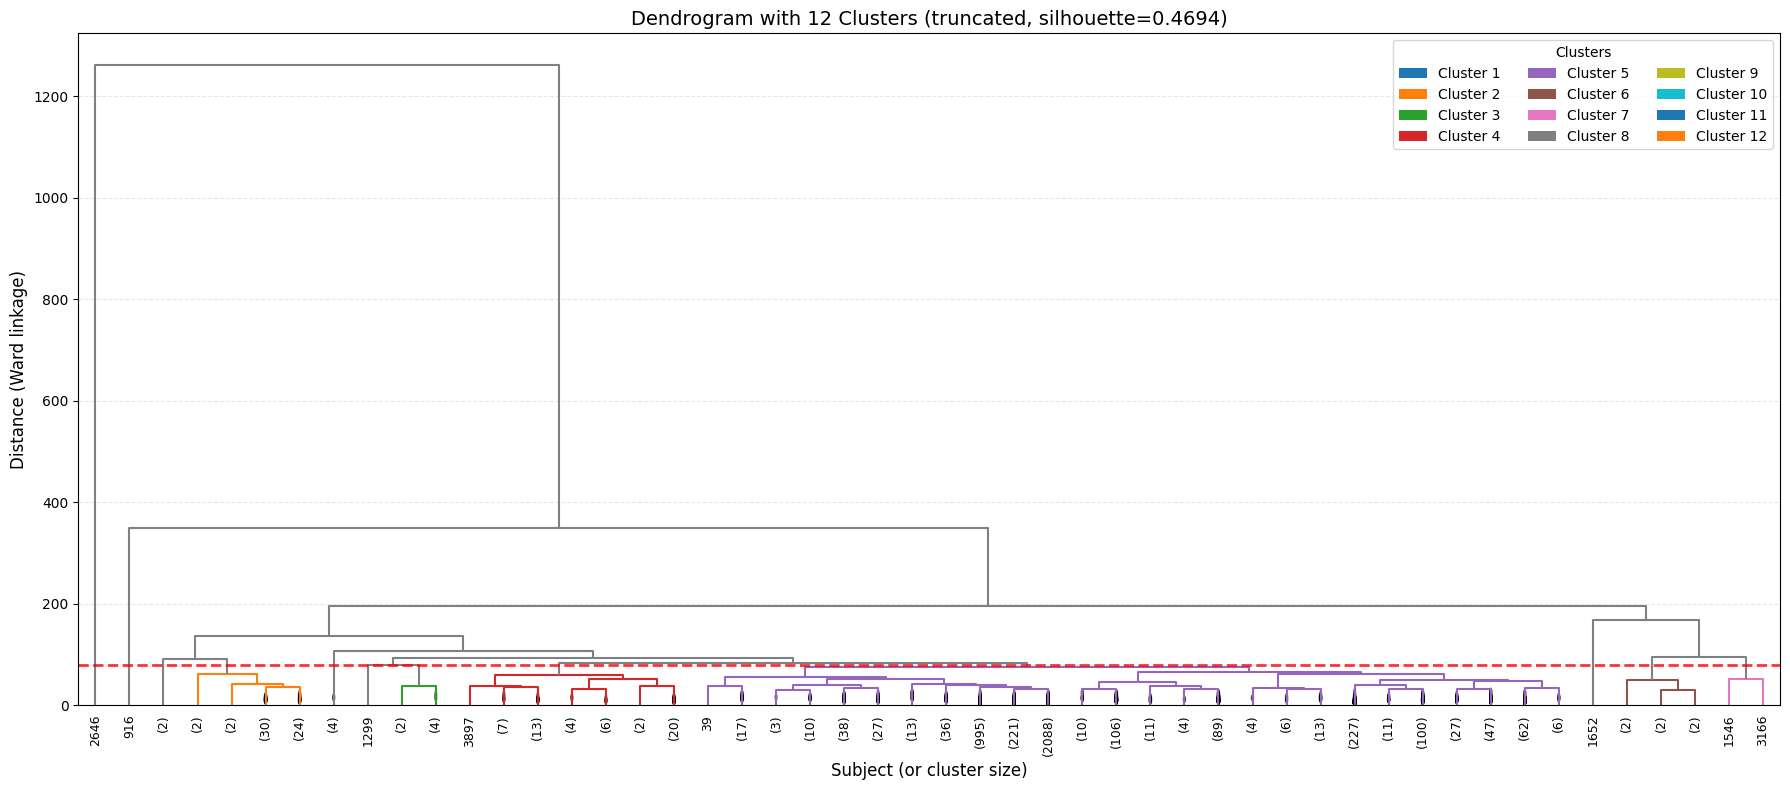

In [109]:
from matplotlib.patches import Patch
from matplotlib.cm import get_cmap

print("\nGenerating truncated dendrogram with 6 colors...")

# ── generate exactly k colors from tab10 ──────────────────────────
cmap   = get_cmap("tab10")
colors = [cmap(i % 10) for i in range(k)]   # always has k entries

fig, ax = plt.subplots(figsize=(18, 8))

cut_height = Z[-(k-1), 2]

R = dendrogram(
    Z,
    truncate_mode='lastp',
    p=50,
    ax=ax,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=cut_height,
    above_threshold_color='gray'
)

ax.axhline(y=cut_height, color='red', linestyle='--', linewidth=2, alpha=0.8)

leaf_order  = R['leaves']
y_min, y_max = ax.get_ylim()
bar_height  = (y_max - y_min) * 0.02
bar_y       = y_min - bar_height * 2

leaf_colors = [colors[i % k] for i in range(len(leaf_order))]

for i, color in enumerate(leaf_colors):
    ax.fill_between([i - 0.5, i + 0.5], bar_y, bar_y + bar_height,
                    color=color, alpha=0.7)

legend_elements = [Patch(facecolor=colors[i], label=f'Cluster {i+1}')
                   for i in range(k)]
ax.legend(handles=legend_elements, loc='upper right',
          title='Clusters', ncol=3, fontsize=10)

ax.set_xlabel('Subject (or cluster size)', fontsize=12)
ax.set_ylabel('Distance (Ward linkage)', fontsize=12)
ax.set_title(f'Dendrogram with {k} Clusters (truncated, silhouette=0.4694)', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## CLUSTER ANALYSIS

In [110]:
best_k =   6

cluster_labels = fcluster(Z, t=best_k, criterion="maxclust") - 1  # 0-indexed
motifs_df["cluster_hier"] = cluster_labels

In [111]:

print("\n" + "="*50)
print("CLUSTER ANALYSIS")
print("="*50)


cluster_counts = motifs_df["cluster_hier"].value_counts().sort_index()
for c, n in cluster_counts.items():
    print(f"  Cluster {c}: {n:4d} subjects  ({100*n/len(motifs_df):.1f}%)")

print("\n--- Subject indices per cluster (first 10 shown) ---")
for c in range(best_k):
    members = motifs_df.loc[motifs_df["cluster_hier"] == c, "sample_index"].tolist()
    print(f"  Cluster {c} ({len(members)} subjects): "
          f"{members[:10]}{'...' if len(members) > 10 else ''}")

# Centroids: subject closest to the mean DTW distance within each cluster
# (more meaningful than mean window for hierarchical)
print("\n--- Most central subject per cluster ---")
for c in range(best_k):
    mask     = np.where(cluster_labels == c)[0]
    sub_dist = dist_mat[np.ix_(mask, mask)]
    central  = mask[np.argmin(sub_dist.mean(axis=1))]
    print(f"  Cluster {c}: most central subject = sample_index "
          f"{motifs_df.iloc[central]['sample_index']}  "
          f"(avg DTW dist = {sub_dist.mean(axis=1).min():.4f})")

# Motif shape summary per cluster per channel
print("\n--- Centroid motif shape summary (mean ± std across cluster members) ---")
for c in range(best_k):
    mask = cluster_labels == c
    print(f"\n  Cluster {c}  (n={mask.sum()}):")
    for i, ch in enumerate(CHANNELS):
        ch_windows = X_3d[mask, :, i]   # (n_members, W)
        mean_pat   = ch_windows.mean(axis=0)
        print(f"    {ch:>8s}: mean={mean_pat.mean():.4f}  "
              f"std={ch_windows.std():.4f}  "
              f"min={mean_pat.min():.4f}  max={mean_pat.max():.4f}")


CLUSTER ANALYSIS
  Cluster 0:   60 subjects  (1.4%)
  Cluster 1: 4236 subjects  (98.4%)
  Cluster 2:    8 subjects  (0.2%)
  Cluster 3:    1 subjects  (0.0%)
  Cluster 4:    1 subjects  (0.0%)
  Cluster 5:    1 subjects  (0.0%)

--- Subject indices per cluster (first 10 shown) ---
  Cluster 0 (60 subjects): [25, 71, 289, 290, 369, 467, 517, 521, 530, 580]...
  Cluster 1 (4236 subjects): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
  Cluster 2 (8 subjects): [1236, 1546, 1747, 2870, 2962, 3166, 3603, 3923]
  Cluster 3 (1 subjects): [1652]
  Cluster 4 (1 subjects): [916]
  Cluster 5 (1 subjects): [2646]

--- Most central subject per cluster ---
  Cluster 0: most central subject = sample_index 1745  (avg DTW dist = 16.6937)
  Cluster 1: most central subject = sample_index 3690  (avg DTW dist = 10.4767)
  Cluster 2: most central subject = sample_index 3603  (avg DTW dist = 34.2372)
  Cluster 3: most central subject = sample_index 1652  (avg DTW dist = 0.0000)
  Cluster 4: most central subject = sampl

In [112]:
def characterize_clusters(
    motifs_df: pd.DataFrame,
    X_3d: np.ndarray,
    km_final,
    CHANNELS: list,
    best_k: int,
    figsize_per_cluster: tuple = (14, 3),
    save_path: str = None,
):
    """
    Full characterization of clustering results on a motif/time-series dataset.

    Parameters
    ----------
    motifs_df   : DataFrame with columns ['sample_index', 'cluster']
    X_3d        : array of shape (n_subjects, W, n_channels) — raw motif data
    km_final    : fitted KMeans object (must have .cluster_centers_)
    CHANNELS    : list of channel names, length == n_channels
    best_k      : number of clusters
    figsize_per_cluster : (width, height) for each cluster's subplot row
    save_path   : if given, saves the figure to this path
    """

    centroids = km_final.cluster_centers_          # (best_k, W, n_channels)
    W          = X_3d.shape[1]
    n_channels = X_3d.shape[2]
    time_axis  = np.arange(W)

    # ------------------------------------------------------------------ #
    # 1. PRINT — cluster sizes
    # ------------------------------------------------------------------ #
    print("\n" + "=" * 60)
    print("  CLUSTER ANALYSIS")
    print("=" * 60)

    print("\n--- Cluster sizes ---")
    cluster_counts = motifs_df["cluster"].value_counts().sort_index()
    for c, n in cluster_counts.items():
        pct = 100 * n / len(motifs_df)
        print(f"  Cluster {c}: {n:4d} subjects  ({pct:.1f}%)")

    # ------------------------------------------------------------------ #
    # 2. PRINT — per-cluster centroid stats
    # ------------------------------------------------------------------ #
    print("\n--- Centroid summary (mean ± std across time steps, per channel) ---")
    for c in range(best_k):
        print(f"\n  Cluster {c}  ({cluster_counts[c]} subjects):")
        for i, ch in enumerate(CHANNELS):
            vals = centroids[c, :, i]
            print(
                f"    {ch:>10s}:  mean={vals.mean():+.4f}  std={vals.std():.4f}"
                f"  min={vals.min():+.4f}  max={vals.max():+.4f}"
            )

    # ------------------------------------------------------------------ #
    # 3. PRINT — intra-cluster distances & cohesion
    # ------------------------------------------------------------------ #
    print("\n--- Intra-cluster cohesion (Euclidean distance to centroid) ---")

    all_flat   = X_3d.reshape(len(X_3d), -1)          # (n_subjects, W*n_channels)
    cent_flat  = centroids.reshape(best_k, -1)         # (best_k,    W*n_channels)

    intra_stats = {}
    for c in range(best_k):
        members_idx = motifs_df.loc[motifs_df["cluster"] == c, "sample_index"].tolist()
        member_data = all_flat[members_idx]             # (n_members, W*n_channels)
        dists       = cdist(member_data, cent_flat[[c]], metric="euclidean").ravel()

        intra_stats[c] = {
            "mean_dist" : dists.mean(),
            "std_dist"  : dists.std(),
            "max_dist"  : dists.max(),
            "min_dist"  : dists.min(),
        }
        print(
            f"  Cluster {c}: mean_dist={dists.mean():.4f}  "
            f"std={dists.std():.4f}  "
            f"min={dists.min():.4f}  max={dists.max():.4f}"
        )

    # ------------------------------------------------------------------ #
    # 4. PRINT — inter-cluster distances (centroid-to-centroid)
    # ------------------------------------------------------------------ #
    print("\n--- Inter-cluster centroid distances ---")
    inter = cdist(cent_flat, cent_flat, metric="euclidean")
    for i in range(best_k):
        for j in range(i + 1, best_k):
            print(f"  Cluster {i} <-> Cluster {j}: {inter[i, j]:.4f}")

    # ------------------------------------------------------------------ #
    # 5. PLOT A — each cluster: one row, one subplot per channel
    #             centroid in bold + all member motifs as faint lines
    # ------------------------------------------------------------------ #
    fig_h = figsize_per_cluster[1] * best_k
    fig, axes = plt.subplots(
        best_k, n_channels,
        figsize=(figsize_per_cluster[0], fig_h),
        sharex=True,
    )
    if best_k == 1:
        axes = axes[np.newaxis, :]   # keep 2-D indexing consistent

    cmap = plt.get_cmap("tab10")

    for c in range(best_k):
        members_idx = motifs_df.loc[motifs_df["cluster"] == c, "sample_index"].tolist()
        color       = cmap(c % 10)

        for i, ch in enumerate(CHANNELS):
            ax = axes[c, i]

            # faint member motifs
            for idx in members_idx:
                ax.plot(time_axis, X_3d[idx, :, i],
                        color=color, alpha=0.15, linewidth=0.6)

            # bold centroid
            ax.plot(time_axis, centroids[c, :, i],
                    color=color, linewidth=2.2, label=f"centroid")

            # ± 1 std band across members at each time step
            member_data = X_3d[members_idx, :, i]     # (n_members, W)
            std_band    = member_data.std(axis=0)
            mean_band   = member_data.mean(axis=0)
            ax.fill_between(
                time_axis,
                mean_band - std_band,
                mean_band + std_band,
                color=color, alpha=0.12,
            )

            if c == 0:
                ax.set_title(ch, fontsize=9, fontweight="bold")
            if i == 0:
                ax.set_ylabel(
                    f"Cluster {c}\n(n={len(members_idx)})",
                    fontsize=8, labelpad=4,
                )
            ax.tick_params(labelsize=7)
            ax.grid(True, linewidth=0.3, alpha=0.5)

    fig.suptitle("Centroid motifs per cluster and channel\n(faint = members, bold = centroid, band = ±1 std)",
                 fontsize=11, y=1.01)
    plt.tight_layout()

    # ------------------------------------------------------------------ #
    # 6. PLOT B — overlay all centroids on the same axes (one per channel)
    # ------------------------------------------------------------------ #
    fig2, axes2 = plt.subplots(
        1, n_channels,
        figsize=(figsize_per_cluster[0], figsize_per_cluster[1] + 1),
        sharex=True,
    )
    if n_channels == 1:
        axes2 = [axes2]

    for i, ch in enumerate(CHANNELS):
        ax2 = axes2[i]
        for c in range(best_k):
            ax2.plot(
                time_axis, centroids[c, :, i],
                color=cmap(c % 10), linewidth=2,
                label=f"C{c} (n={cluster_counts[c]})",
            )
        ax2.set_title(ch, fontsize=9, fontweight="bold")
        ax2.legend(fontsize=7, loc="upper right")
        ax2.grid(True, linewidth=0.3, alpha=0.5)
        ax2.tick_params(labelsize=7)

    fig2.suptitle("Centroid comparison across clusters (per channel)",
                  fontsize=11)
    plt.tight_layout()

    # ------------------------------------------------------------------ #
    # 7. PLOT C — intra-cluster cohesion bar chart
    # ------------------------------------------------------------------ #
    fig3, ax3 = plt.subplots(figsize=(max(5, best_k * 1.5), 4))
    means = [intra_stats[c]["mean_dist"] for c in range(best_k)]
    stds  = [intra_stats[c]["std_dist"]  for c in range(best_k)]
    bars  = ax3.bar(
        range(best_k), means, yerr=stds,
        color=[cmap(c % 10) for c in range(best_k)],
        capsize=5, edgecolor="white", linewidth=0.8,
    )
    ax3.set_xticks(range(best_k))
    ax3.set_xticklabels([f"Cluster {c}" for c in range(best_k)], fontsize=9)
    ax3.set_ylabel("Mean Euclidean distance to centroid", fontsize=9)
    ax3.set_title("Intra-cluster cohesion (lower = tighter cluster)", fontsize=11)
    ax3.grid(axis="y", linewidth=0.3, alpha=0.5)
    for bar, m in zip(bars, means):
        ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + stds[means.index(m)] * 0.05,
                 f"{m:.3f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path.replace(".png", "_motifs.png"), dpi=150, bbox_inches="tight")
        fig2.savefig(save_path.replace(".png", "_comparison.png"), dpi=150, bbox_inches="tight")
        fig3.savefig(save_path.replace(".png", "_cohesion.png"), dpi=150, bbox_inches="tight")
        print(f"\n✅ Figures saved to {save_path} (3 files)")

    plt.show()
    return intra_stats





  CLUSTER ANALYSIS

--- Cluster sizes ---
  Cluster 0:   60 subjects  (1.4%)
  Cluster 1: 4236 subjects  (98.4%)
  Cluster 2:    8 subjects  (0.2%)
  Cluster 3:    1 subjects  (0.0%)
  Cluster 4:    1 subjects  (0.0%)
  Cluster 5:    1 subjects  (0.0%)

--- Centroid summary (mean ± std across time steps, per channel) ---

  Cluster 0  (60 subjects):
             X:  mean=+0.3281  std=0.0412  min=+0.2542  max=+0.3805
             Y:  mean=+0.0050  std=0.0514  min=-0.0940  max=+0.0919
             Z:  mean=+1.0739  std=0.1026  min=+0.8463  max=+1.2185
          enmo:  mean=+0.4658  std=0.4248  min=+0.0846  max=+1.5958
        anglez:  mean=+5.5480  std=0.3330  min=+4.9973  max=+6.0975
         light:  mean=-0.5680  std=0.1477  min=-0.8143  max=-0.3299

  Cluster 1  (4236 subjects):
             X:  mean=+0.1584  std=0.0106  min=+0.1477  max=+0.1858
             Y:  mean=+0.0003  std=0.0081  min=-0.0164  max=+0.0166
             Z:  mean=+0.0403  std=0.0165  min=+0.0169  max=+0.0690
    

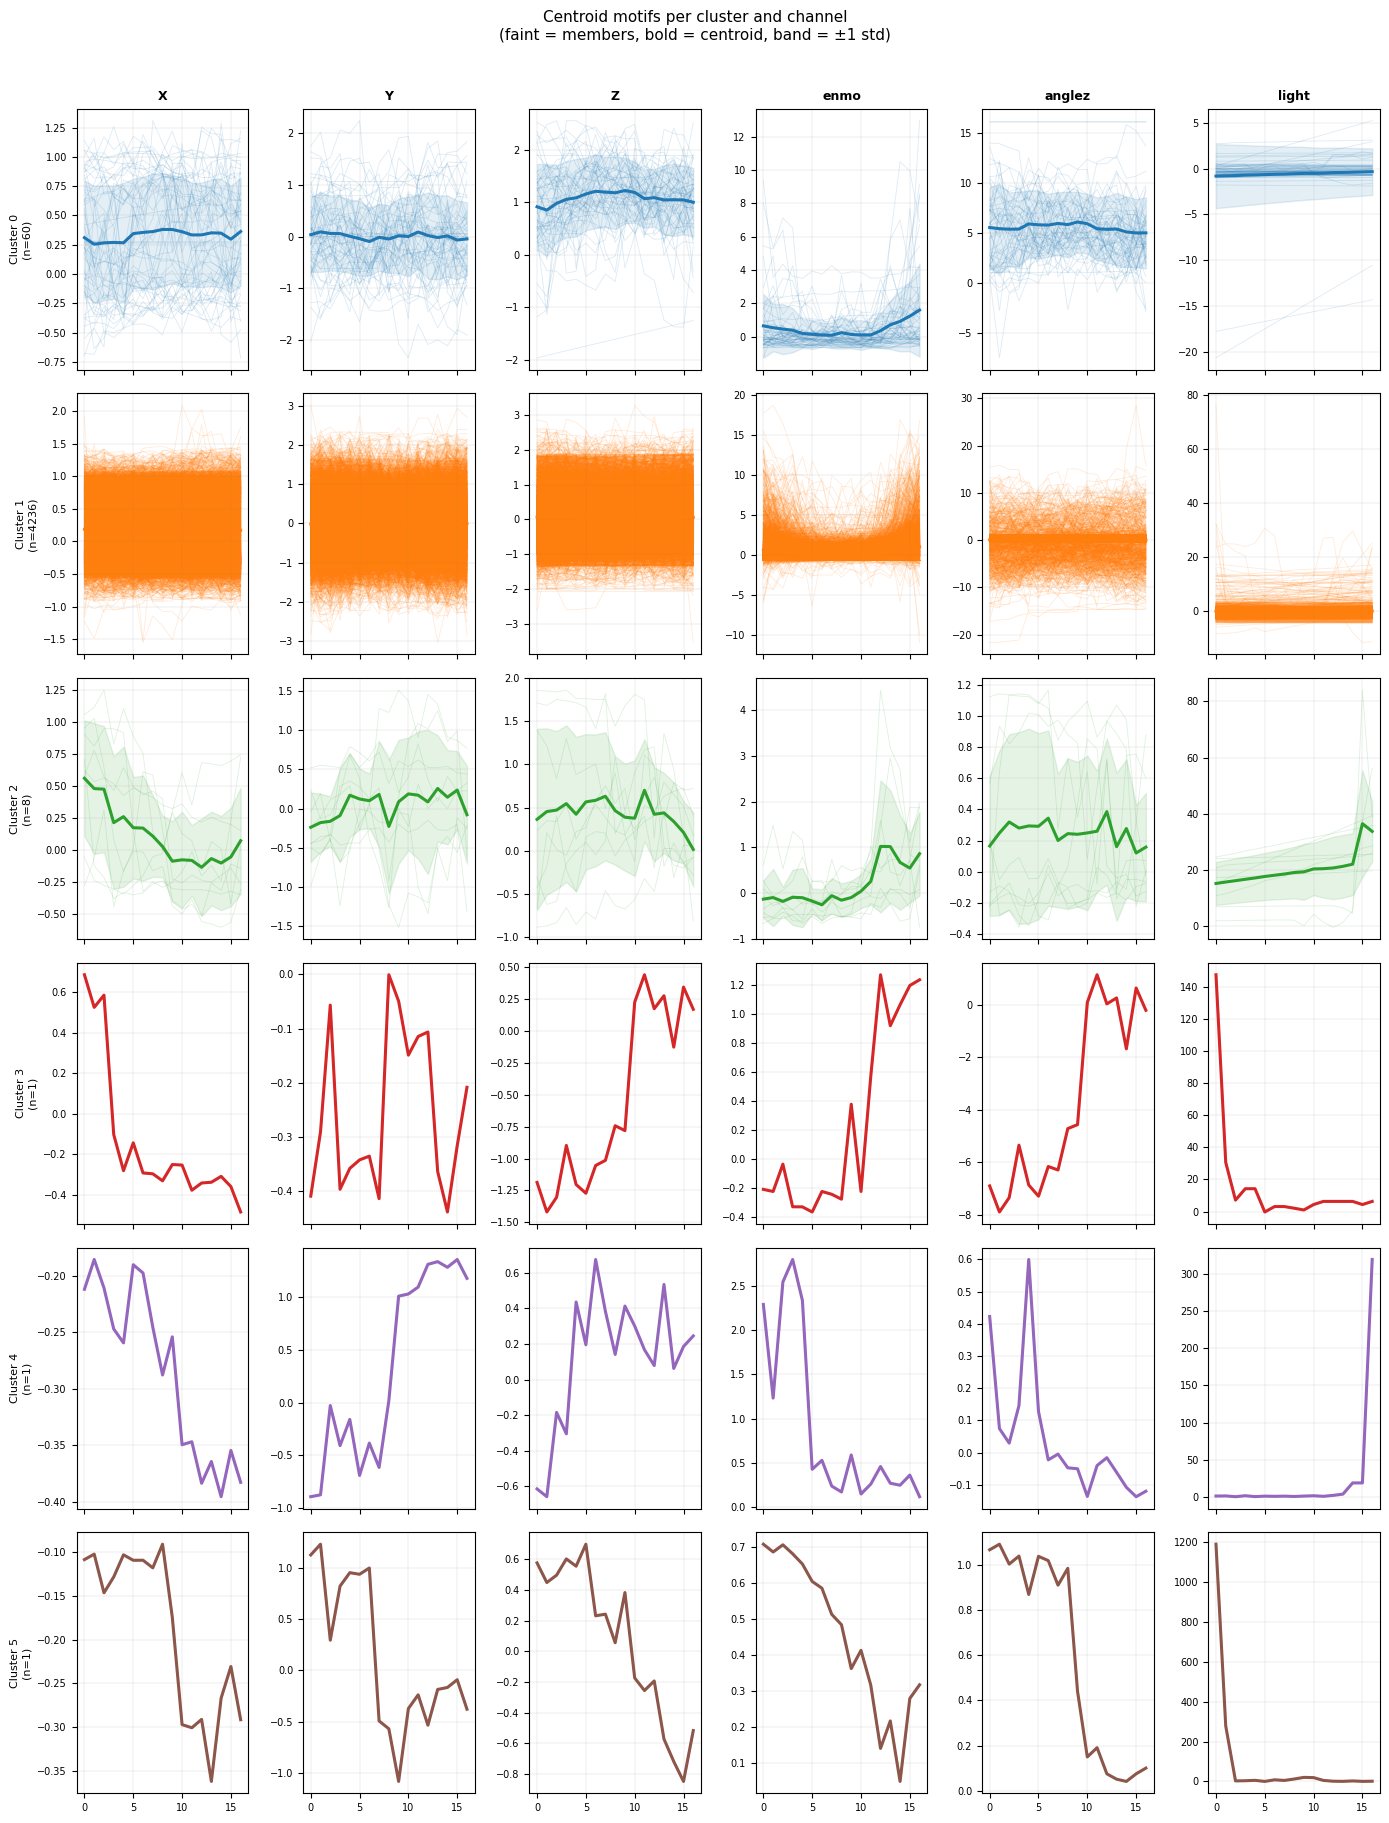

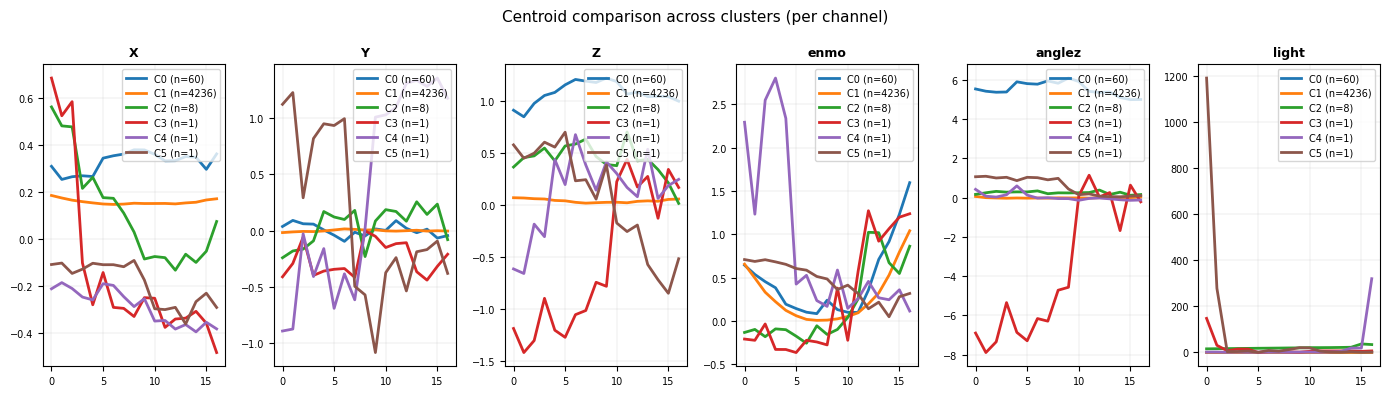

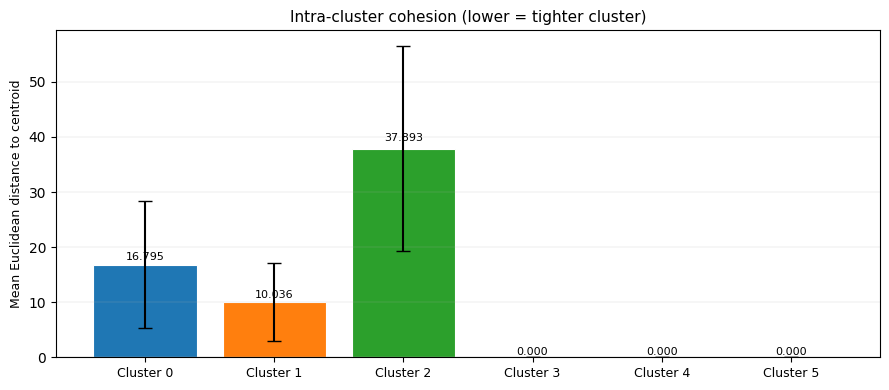

In [113]:
# Calcola centroidi manualmente dall'hierarchical clustering
centroids_hier = np.array([
    X_3d[motifs_df.loc[motifs_df["cluster_hier"] == c, "sample_index"].tolist()].mean(axis=0)
    for c in range(best_k)
])  # shape: (best_k, W, n_channels)

class FakeCentroids:
    def __init__(self, centers):
        self.cluster_centers_ = centers

intra_stats = characterize_clusters(
    motifs_df = motifs_df.rename(columns={"cluster_hier": "cluster"}),
    X_3d      = X_3d,
    km_final  = FakeCentroids(centroids_hier),
    CHANNELS  = CHANNELS,
    best_k    = best_k,
    save_path = "cluster_analysis.png",
)

In [114]:
def characterize_clusters(
    motifs_df: pd.DataFrame,
    X_3d: np.ndarray,
    km_final,                              # accepts FakeCentroids too
    CHANNELS: list,
    best_k: int,
    y_labels: np.ndarray = None,           # ← NEW: array of 0/1 labels
    figsize_per_cluster: tuple = (14, 3),
    save_path: str = None,
):
    """
    Full characterization of clustering results on a motif/time-series dataset.

    Parameters
    ----------
    motifs_df   : DataFrame with columns ['sample_index', 'cluster']
    X_3d        : array of shape (n_subjects, W, n_channels) — raw motif data
    km_final    : fitted KMeans / FakeCentroids object (must have .cluster_centers_)
    CHANNELS    : list of channel names, length == n_channels
    best_k      : number of clusters
    y_labels    : optional array of binary labels (0/1), length == len(X_3d)
    figsize_per_cluster : (width, height) for each cluster's subplot row
    save_path   : if given, saves the figure to this path
    """

    centroids  = km_final.cluster_centers_          # (best_k, W, n_channels)
    W          = X_3d.shape[1]
    n_channels = X_3d.shape[2]
    time_axis  = np.arange(W)

    # ------------------------------------------------------------------ #
    # 1. PRINT — cluster sizes
    # ------------------------------------------------------------------ #
    print("\n" + "=" * 60)
    print("  CLUSTER ANALYSIS")
    print("=" * 60)

    print("\n--- Cluster sizes ---")
    cluster_counts = motifs_df["cluster"].value_counts().sort_index()
    for c, n in cluster_counts.items():
        pct = 100 * n / len(motifs_df)
        print(f"  Cluster {c}: {n:4d} subjects  ({pct:.1f}%)")

    # ------------------------------------------------------------------ #
    # 2. PRINT — label distribution per cluster              ← NEW
    # ------------------------------------------------------------------ #
    label_stats = {}
    if y_labels is not None:
        print("\n--- Label distribution per cluster (sii_binary) ---")
        for c in range(best_k):
            members_idx = motifs_df.loc[motifs_df["cluster"] == c, "sample_index"].tolist()
            labels_c    = y_labels[members_idx]
            n0    = int((labels_c == 0).sum())
            n1    = int((labels_c == 1).sum())
            total = len(labels_c)
            pct0  = 100 * n0 / total if total > 0 else 0
            pct1  = 100 * n1 / total if total > 0 else 0
            label_stats[c] = {"n0": n0, "n1": n1, "pct0": pct0, "pct1": pct1}
            print(
                f"  Cluster {c}: "
                f"label=0 → {n0:4d} ({pct0:.1f}%)   "
                f"label=1 → {n1:4d} ({pct1:.1f}%)   "
                f"[majority: {'0' if n0 >= n1 else '1'}]"
            )

    # ------------------------------------------------------------------ #
    # 3. PRINT — per-cluster centroid stats
    # ------------------------------------------------------------------ #
    print("\n--- Centroid summary (mean ± std across time steps, per channel) ---")
    for c in range(best_k):
        print(f"\n  Cluster {c}  ({cluster_counts[c]} subjects):")
        for i, ch in enumerate(CHANNELS):
            vals = centroids[c, :, i]
            print(
                f"    {ch:>10s}:  mean={vals.mean():+.4f}  std={vals.std():.4f}"
                f"  min={vals.min():+.4f}  max={vals.max():+.4f}"
            )

    # ------------------------------------------------------------------ #
    # 4. PRINT — intra-cluster distances & cohesion
    # ------------------------------------------------------------------ #
    print("\n--- Intra-cluster cohesion (Euclidean distance to mean centroid) ---")

    all_flat  = X_3d.reshape(len(X_3d), -1)
    cent_flat = centroids.reshape(best_k, -1)

    intra_stats = {}
    for c in range(best_k):
        members_idx = motifs_df.loc[motifs_df["cluster"] == c, "sample_index"].tolist()
        member_data = all_flat[members_idx]
        dists       = cdist(member_data, cent_flat[[c]], metric="euclidean").ravel()

        intra_stats[c] = {
            "mean_dist": dists.mean(),
            "std_dist" : dists.std(),
            "max_dist" : dists.max(),
            "min_dist" : dists.min(),
        }
        print(
            f"  Cluster {c}: mean_dist={dists.mean():.4f}  "
            f"std={dists.std():.4f}  "
            f"min={dists.min():.4f}  max={dists.max():.4f}"
        )

    # ------------------------------------------------------------------ #
    # 5. PRINT — inter-cluster distances (centroid-to-centroid)
    # ------------------------------------------------------------------ #
    print("\n--- Inter-cluster centroid distances (Euclidean, mean centroids) ---")
    inter = cdist(cent_flat, cent_flat, metric="euclidean")
    for i in range(best_k):
        for j in range(i + 1, best_k):
            print(f"  Cluster {i} <-> Cluster {j}: {inter[i, j]:.4f}")

    # ------------------------------------------------------------------ #
    # 6. PLOT A — centroid motifs per cluster
    # ------------------------------------------------------------------ #
    fig_h = figsize_per_cluster[1] * best_k
    fig, axes = plt.subplots(
        best_k, n_channels,
        figsize=(figsize_per_cluster[0], fig_h),
        sharex=True,
    )
    if best_k == 1:
        axes = axes[np.newaxis, :]

    cmap = plt.get_cmap("tab10")

    for c in range(best_k):
        members_idx = motifs_df.loc[motifs_df["cluster"] == c, "sample_index"].tolist()
        color       = cmap(c % 10)

        for i, ch in enumerate(CHANNELS):
            ax = axes[c, i]

            for idx in members_idx:
                ax.plot(time_axis, X_3d[idx, :, i],
                        color=color, alpha=0.15, linewidth=0.6)

            ax.plot(time_axis, centroids[c, :, i],
                    color=color, linewidth=2.2, label="centroid")

            member_data = X_3d[members_idx, :, i]
            std_band    = member_data.std(axis=0)
            mean_band   = member_data.mean(axis=0)
            ax.fill_between(
                time_axis,
                mean_band - std_band,
                mean_band + std_band,
                color=color, alpha=0.12,
            )

            if c == 0:
                ax.set_title(ch, fontsize=9, fontweight="bold")
            if i == 0:
                # include label counts in y-label              ← NEW
                if y_labels is not None and c in label_stats:
                    s = label_stats[c]
                    ax.set_ylabel(
                        f"Cluster {c}\n(n={len(members_idx)})\n"
                        f"0:{s['n0']} 1:{s['n1']}",
                        fontsize=8, labelpad=4,
                    )
                else:
                    ax.set_ylabel(
                        f"Cluster {c}\n(n={len(members_idx)})",
                        fontsize=8, labelpad=4,
                    )
            ax.tick_params(labelsize=7)
            ax.grid(True, linewidth=0.3, alpha=0.5)

    fig.suptitle(
        "Centroid motifs per cluster and channel\n(faint = members, bold = centroid, band = ±1 std)",
        fontsize=11, y=1.01,
    )
    plt.tight_layout()

    # ------------------------------------------------------------------ #
    # 7. PLOT B — centroid comparison
    # ------------------------------------------------------------------ #
    fig2, axes2 = plt.subplots(
        1, n_channels,
        figsize=(figsize_per_cluster[0], figsize_per_cluster[1] + 1),
        sharex=True,
    )
    if n_channels == 1:
        axes2 = [axes2]

    for i, ch in enumerate(CHANNELS):
        ax2 = axes2[i]
        for c in range(best_k):
            if y_labels is not None and c in label_stats:       # ← NEW
                s   = label_stats[c]
                lbl = f"C{c} (n={cluster_counts[c]}, 0:{s['n0']} 1:{s['n1']})"
            else:
                lbl = f"C{c} (n={cluster_counts[c]})"
            ax2.plot(time_axis, centroids[c, :, i],
                     color=cmap(c % 10), linewidth=2, label=lbl)
        ax2.set_title(ch, fontsize=9, fontweight="bold")
        ax2.legend(fontsize=7, loc="upper right")
        ax2.grid(True, linewidth=0.3, alpha=0.5)
        ax2.tick_params(labelsize=7)

    fig2.suptitle("Centroid comparison across clusters (per channel)", fontsize=11)
    plt.tight_layout()

    # ------------------------------------------------------------------ #
    # 8. PLOT C — intra-cluster cohesion bar chart
    # ------------------------------------------------------------------ #
    fig3, ax3 = plt.subplots(figsize=(max(5, best_k * 1.5), 4))
    means = [intra_stats[c]["mean_dist"] for c in range(best_k)]
    stds  = [intra_stats[c]["std_dist"]  for c in range(best_k)]
    bars  = ax3.bar(
        range(best_k), means, yerr=stds,
        color=[cmap(c % 10) for c in range(best_k)],
        capsize=5, edgecolor="white", linewidth=0.8,
    )
    ax3.set_xticks(range(best_k))
    ax3.set_xticklabels([f"Cluster {c}" for c in range(best_k)], fontsize=9)
    ax3.set_ylabel("Mean Euclidean distance to centroid", fontsize=9)
    ax3.set_title(
        "Intra-cluster cohesion — Euclidean dist to mean centroid\n"
        "(note: clustering was DTW-based)",
        fontsize=10,
    )
    ax3.grid(axis="y", linewidth=0.3, alpha=0.5)
    for bar, m in zip(bars, means):
        ax3.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + stds[means.index(m)] * 0.05,
            f"{m:.3f}", ha="center", va="bottom", fontsize=8,
        )
    plt.tight_layout()

    # ------------------------------------------------------------------ #
    # 9. PLOT D — label distribution stacked bar chart       ← NEW
    # ------------------------------------------------------------------ #
    if y_labels is not None:
        fig4, ax4 = plt.subplots(figsize=(max(5, best_k * 1.5), 4))
        n0s = [label_stats[c]["n0"] for c in range(best_k)]
        n1s = [label_stats[c]["n1"] for c in range(best_k)]
        x   = np.arange(best_k)

        ax4.bar(x, n0s, color="steelblue", label="label = 0", edgecolor="white")
        ax4.bar(x, n1s, bottom=n0s, color="tomato", label="label = 1", edgecolor="white")

        for c in range(best_k):
            total = n0s[c] + n1s[c]
            if total > 0:
                ax4.text(c, n0s[c] / 2,
                         f"{100*n0s[c]/total:.0f}%",
                         ha="center", va="center", fontsize=8,
                         color="white", fontweight="bold")
                ax4.text(c, n0s[c] + n1s[c] / 2,
                         f"{100*n1s[c]/total:.0f}%",
                         ha="center", va="center", fontsize=8,
                         color="white", fontweight="bold")

        ax4.set_xticks(x)
        ax4.set_xticklabels(
            [f"Cluster {c}\n(n={cluster_counts[c]})" for c in range(best_k)],
            fontsize=9,
        )
        ax4.set_ylabel("Number of subjects", fontsize=9)
        ax4.set_title("Label distribution per cluster (sii_binary)", fontsize=11)
        ax4.legend(fontsize=9)
        ax4.grid(axis="y", linewidth=0.3, alpha=0.5)
        plt.tight_layout()

    # ------------------------------------------------------------------ #
    # Save
    # ------------------------------------------------------------------ #
    if save_path:
        fig.savefig(save_path.replace(".png", "_motifs.png"),      dpi=150, bbox_inches="tight")
        fig2.savefig(save_path.replace(".png", "_comparison.png"), dpi=150, bbox_inches="tight")
        fig3.savefig(save_path.replace(".png", "_cohesion.png"),   dpi=150, bbox_inches="tight")
        if y_labels is not None:
            fig4.savefig(save_path.replace(".png", "_labels.png"), dpi=150, bbox_inches="tight")
        n_saved = 4 if y_labels is not None else 3
        print(f"\n✅ Figures saved to {save_path} ({n_saved} files)")

    plt.show()
    return intra_stats


  CLUSTER ANALYSIS

--- Cluster sizes ---
  Cluster 0:   60 subjects  (1.4%)
  Cluster 1: 4236 subjects  (98.4%)
  Cluster 2:    8 subjects  (0.2%)
  Cluster 3:    1 subjects  (0.0%)
  Cluster 4:    1 subjects  (0.0%)
  Cluster 5:    1 subjects  (0.0%)

--- Label distribution per cluster (sii_binary) ---
  Cluster 0: label=0 →   34 (56.7%)   label=1 →   26 (43.3%)   [majority: 0]
  Cluster 1: label=0 → 2847 (67.2%)   label=1 → 1389 (32.8%)   [majority: 0]
  Cluster 2: label=0 →    5 (62.5%)   label=1 →    3 (37.5%)   [majority: 0]
  Cluster 3: label=0 →    0 (0.0%)   label=1 →    1 (100.0%)   [majority: 1]
  Cluster 4: label=0 →    1 (100.0%)   label=1 →    0 (0.0%)   [majority: 0]
  Cluster 5: label=0 →    0 (0.0%)   label=1 →    1 (100.0%)   [majority: 1]

--- Centroid summary (mean ± std across time steps, per channel) ---

  Cluster 0  (60 subjects):
             X:  mean=+0.3281  std=0.0412  min=+0.2542  max=+0.3805
             Y:  mean=+0.0050  std=0.0514  min=-0.0940  max=+0.0

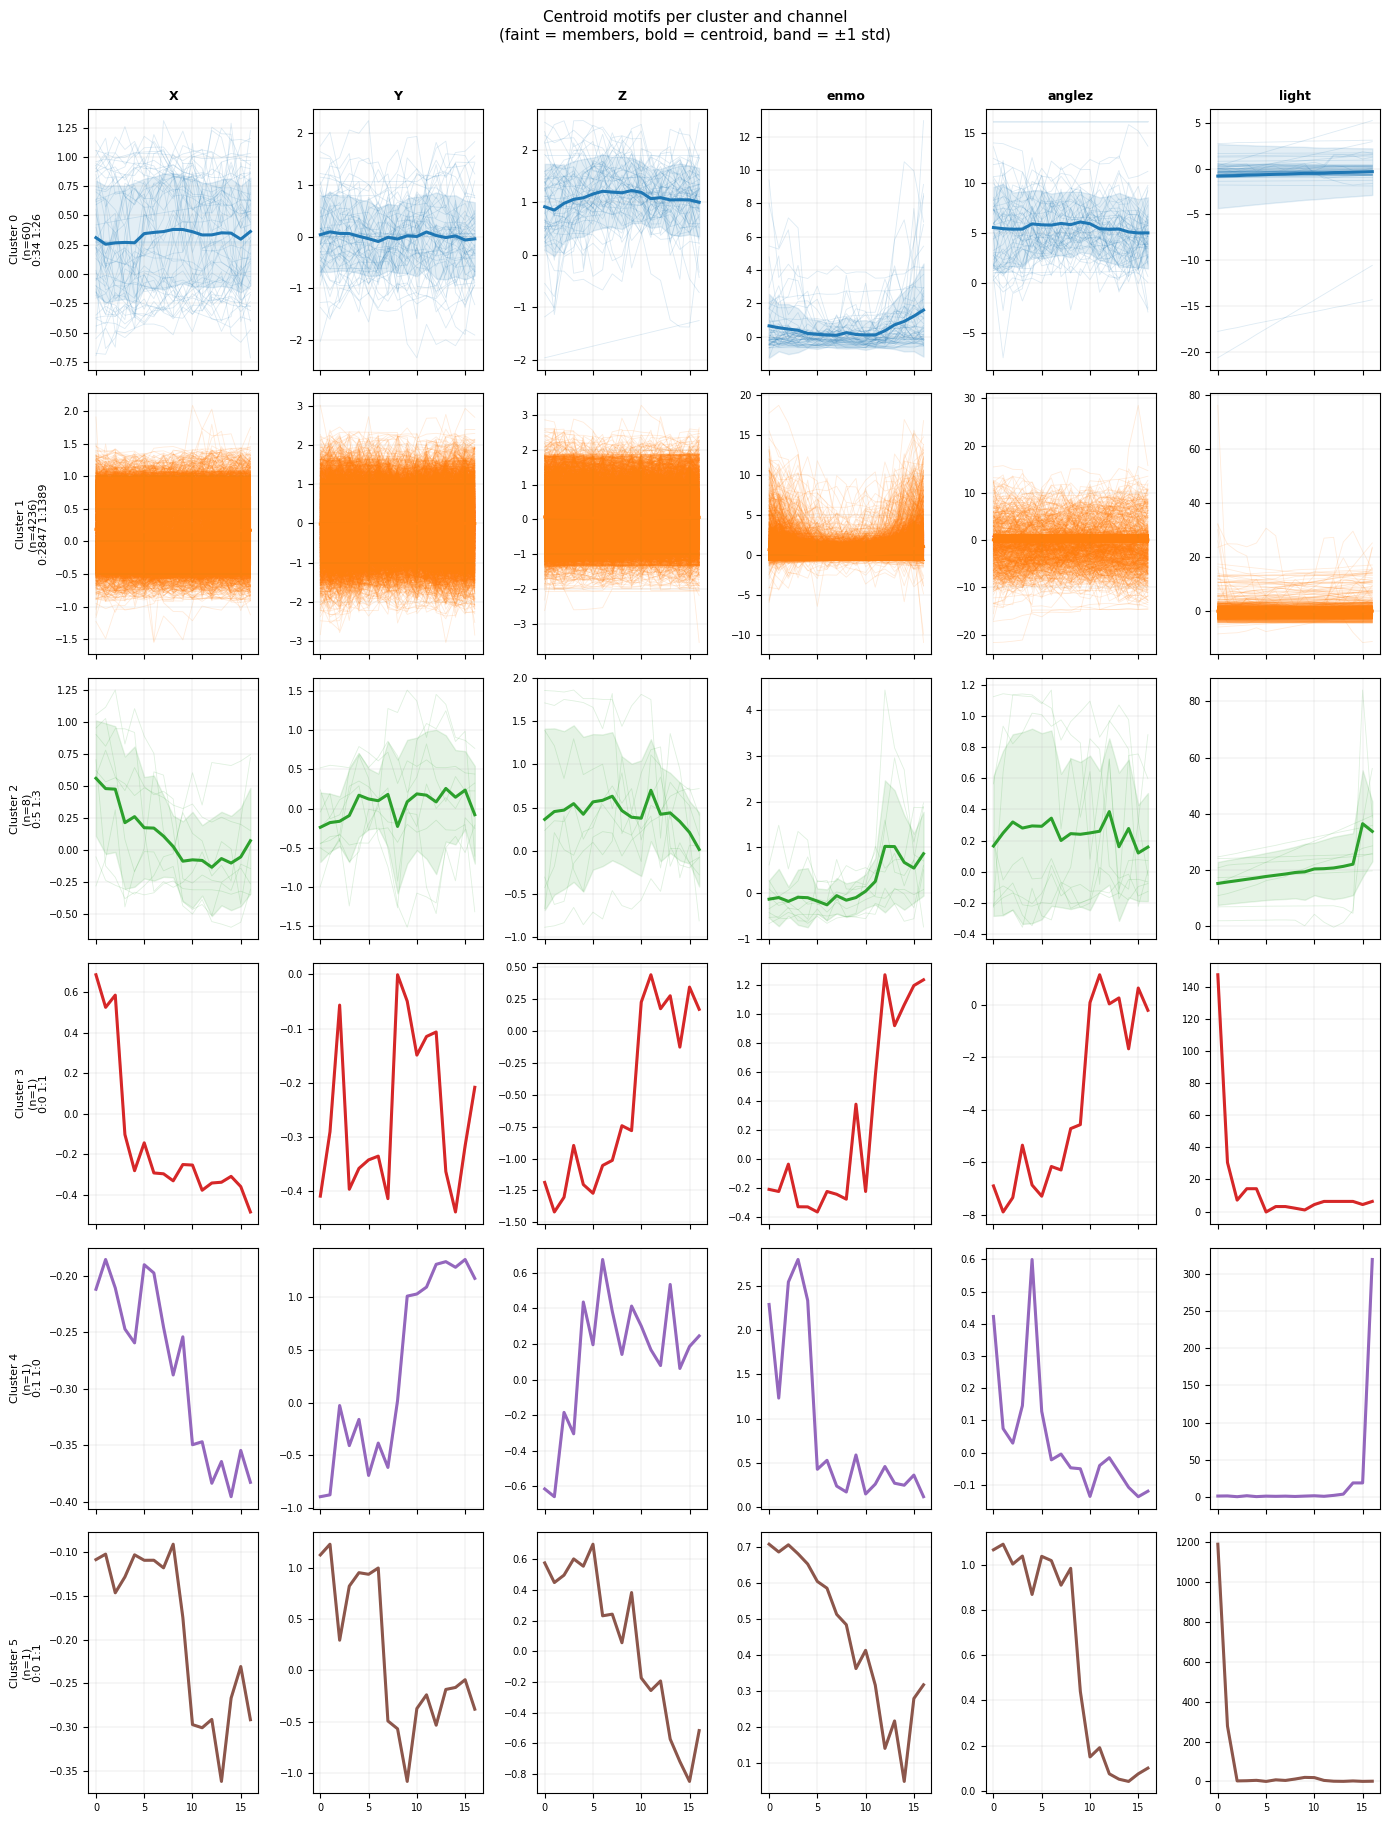

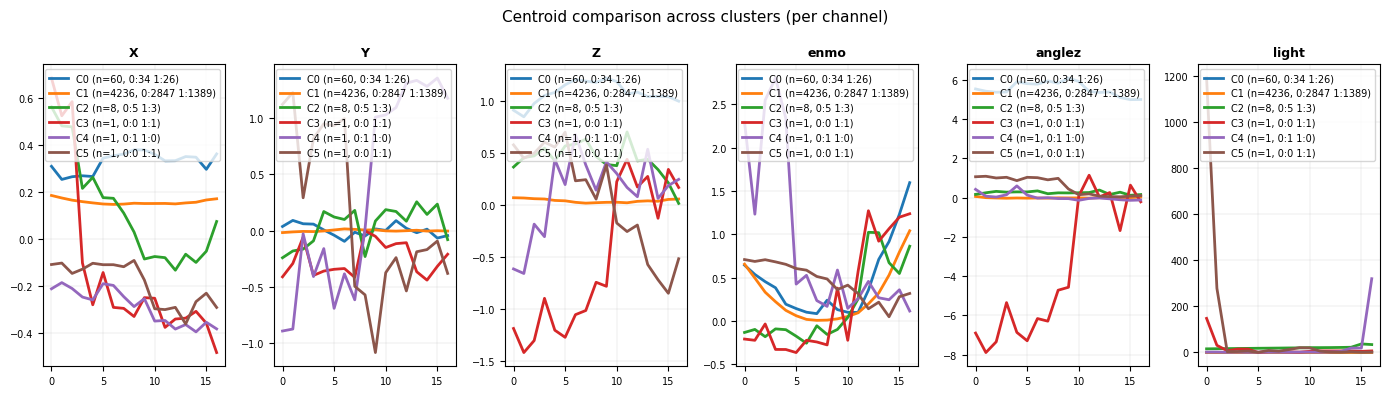

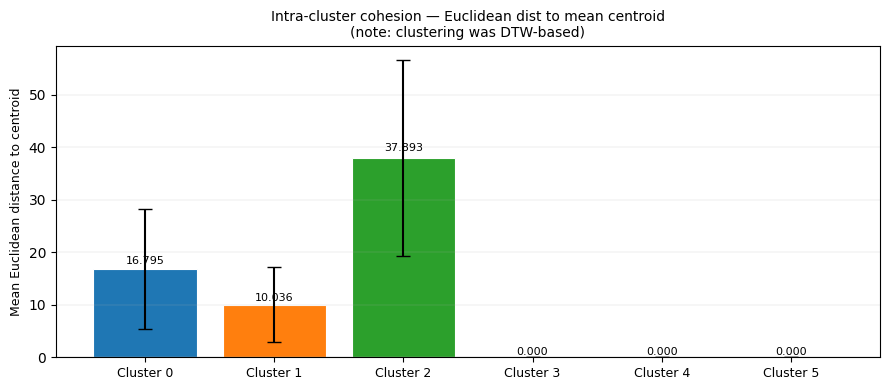

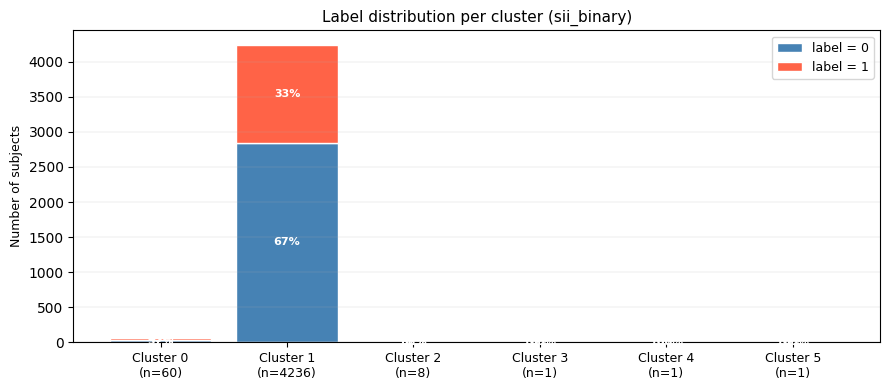

In [115]:
intra_stats = characterize_clusters(
    motifs_df = motifs_df.rename(columns={"cluster_hier": "cluster"}),
    X_3d      = X_3d,
    km_final  = FakeCentroids(centroids_hier),
    CHANNELS  = CHANNELS,
    best_k    = best_k,
    y_labels  = y_labels.astype(int),          # ← new
    save_path = "cluster_analysis.png",
)

In [116]:
# # Calcola centroidi manualmente dall'hierarchical clustering
# centroids_hier = np.array([
#     X_3d[motifs_df.loc[motifs_df["cluster_hier"] == c, "sample_index"].tolist()].mean(axis=0)
#     for c in range(best_k)
# ])  # shape: (best_k, W, n_channels)

# class FakeCentroids:
#     def _init_(self, centers):
#         self.cluster_centers_ = centers

# intra_stats = characterize_clusters(
#     motifs_df = motifs_df.rename(columns={"cluster_hier": "cluster"}),
#     X_3d      = X_3d,
#     km_final  = FakeCentroids(centroids_hier),
#     CHANNELS  = CHANNELS,
#     best_k    = best_k,
#     save_path = "cluster_analysis.png",
# )

In [117]:
# # Calcola centroidi manualmente dall'hierarchical clustering
# centroids_hier = np.array([
# X_3d[motifs_df.loc[motifs_df["cluster_hier"] == c, "sample_index"].tolist()].mean(axis=0)
# for c in range(best_k)
# ])  # shape: (best_k, W, n_channels)

# class FakeCentroids:
#     def _init_(self, centers):
#         self.cluster_centers_ = centers

# intra_stats = characterize_clusters(
#     motifs_df   = motifs_df.rename(columns={"cluster_hier": "cluster"}),
#     X_3d        = X_3d,
#     km_final    = FakeCentroids(centroids_hier),
#     CHANNELS    = CHANNELS,
#     best_k      = best_k,
#     y_labels    = y_labels.astype(int),   # ← pass here
# )

## PCA + t-SNE

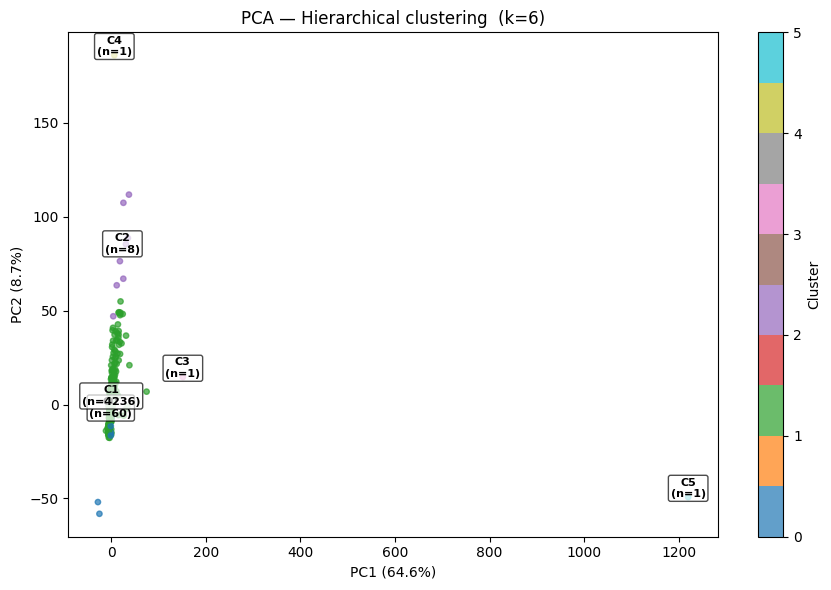

Running t-SNE ...


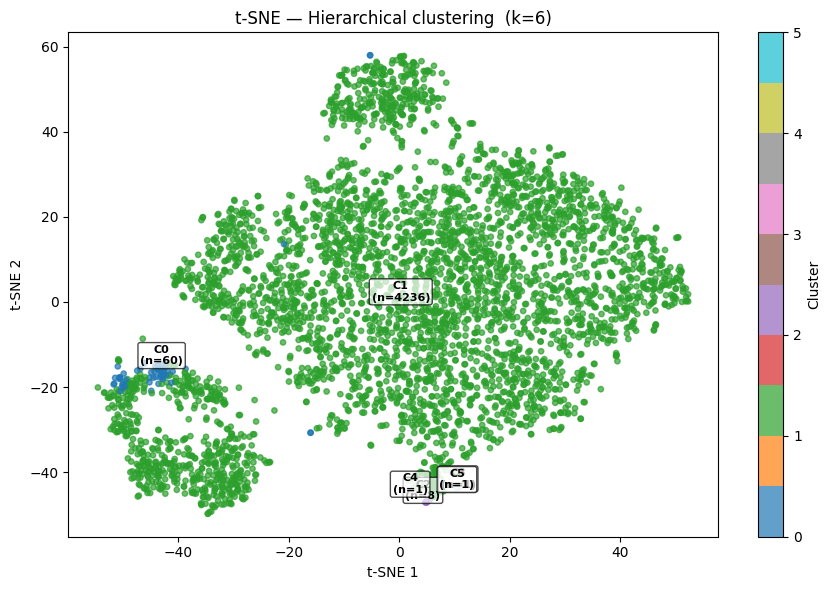

In [118]:
CMAP   = "tab10"
X_flat = X_3d.reshape(len(X_3d), -1)

# — PCA
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_flat)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                c=cluster_labels, cmap=CMAP, s=15, alpha=0.7)
for c in range(best_k):
    mask = cluster_labels == c
    cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
    ax.annotate(f"C{c}\n(n={mask.sum()})", (cx, cy), fontsize=8,
                fontweight="bold", ha="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
ax.set_title(f"PCA — Hierarchical clustering  (k={best_k})")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.colorbar(sc, ax=ax, label="Cluster")
plt.tight_layout()

plt.show()


# — t-SNE (precomputed DTW distances)
print("Running t-SNE ...")
tsne   = TSNE(n_components=2, perplexity=30, random_state=42,
              metric="precomputed", init="random")
X_tsne = tsne.fit_transform(dist_mat)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
                c=cluster_labels, cmap=CMAP, s=15, alpha=0.7)
for c in range(best_k):
    mask = cluster_labels == c
    cx, cy = X_tsne[mask, 0].mean(), X_tsne[mask, 1].mean()
    ax.annotate(f"C{c}\n(n={mask.sum()})", (cx, cy), fontsize=8,
                fontweight="bold", ha="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
ax.set_title(f"t-SNE — Hierarchical clustering  (k={best_k})")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
plt.colorbar(sc, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()